In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.special import erf
import csv
import sys
sys.path.append('/storage/home/hcoda1/4/ashelby8/Manitoba/pyNab/src/')
import nabPy as Nab
sys.path.append('/storage/home/hcoda1/4/ashelby8/calibration/calibration/')
from FitClass import SnCalibration
from FitClass import CdCalibration
from config import conf
import FitFuncs
import pandas as pd
import pylab as py
np.set_printoptions(threshold=sys.maxsize)
pd.set_option("display.max_colwidth", 15)

In [14]:
runs = [1389,1374,1391,1392,1393]
runs2 = [1375,1376,1377,1379,1381,1383,1385]
# runs = [1375,1376,1377,1379,1381]
# 1389,1374,1391,1392,1393,1395
runs_Cd = [1749,1751,1756,1763]
# 1749,1751,1756,1763,1769,1772
bias = [-320,-300,-250,-180,-120]
bias2 = [-320,-300,-250,-210,-180,-150,-120]

In [15]:
data = []
for i in range(len(runs2)):
    with open('/storage/home/hcoda1/4/ashelby8/output%d.csv'%runs2[i]) as f:
        csv.DictReader(f)
        data.append(pd.read_csv(f))
dataAll = pd.concat(data,ignore_index = True)

In [4]:
data = []
for i in range(len(runs_Cd)):
    with open('/storage/home/hcoda1/4/ashelby8/output%d.csv'%runs_Cd[i]) as f:
        csv.DictReader(f)
        data.append(pd.read_csv(f))
dataAll_Cd = pd.concat(data,ignore_index = True)

In [5]:
df = {}
j = 0
for i in range(5):
    df[j] = np.float64(dataAll[dataAll['pixel']==114]['xray'].iloc[i].replace('[','').replace(']','').split()).tolist()
    j +=1

In [14]:
dataAll

,run,pixel,Bias Voltage,Proton,trap rise,trap length,trap decay,Proton Energy,Cd109,Sn113,...,ecap,chi2_e,xray,chi2_x,CE,Xray,CE hist,Xray hist,CE errors,Xray errors
0,1389,76,-320,False,1250,50,1250,0,False,True,...,[ 1.0568062...,0.428389,[ 3.0319763...,47.417368,3,4,[ 0 0 0 ...,[670 494 31...,[[ 8.450475...,[[ 8.709173...
1,1389,77,-320,False,1250,50,1250,0,False,True,...,[ 1.1491791...,0.450345,[ 2.0287735...,27.605397,2,5,[ 0 0 0 ...,[607 423 31...,[[ 1.771316...,[[ 1.448545...
2,1389,78,-320,False,1250,50,1250,0,False,True,...,[ 8.3462016...,0.382993,[ 1.4337784...,20.870130,2,4,[ 2 0 0 ...,[153 140 8...,[[ 6.633161...,[[ 6.892329...
3,1389,87,-320,False,1250,50,1250,0,False,True,...,[ 9.2351523...,0.376442,[ 1.2191124...,202.725472,2,5,[ 1 0 0 ...,[749 733 61...,[[ 7.236030...,[[ 1.857618...
4,1389,88,-320,False,1250,50,1250,0,False,True,...,[ 9.2337829...,0.377683,[ 2.1418771...,22.794588,2,5,[ 0 0 0 ...,[1057 833 ...,[[ 7.143896...,[[ 2.651382...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
142,1399,116,-60,False,1250,50,1250,0,False,True,...,[ 5.0943558...,0.006609,[ 2.6678516...,10.762793,0,0,[0 0 0 0 0 ...,[481 437 32...,[[inf inf i...,[[ 6.159131...
143,1399,121,-60,False,1250,50,1250,0,False,True,...,[ 1.9708398...,0.174893,[ 5.3561326...,35.023138,2,4,[0 1 0 0 0 ...,[242 232 15...,[[ 2.322918...,[[ 1.355253...
144,1399,122,-60,False,1250,50,1250,0,False,True,...,[ 4.7681793...,0.207843,[ 1.9161306...,60.928057,2,4,[0 0 0 0 0 ...,[652 444 35...,[[ 2.112511...,[[ 1.103053...
145,1399,123,-60,False,1250,50,1250,0,False,True,...,[ 1.2548158...,0.122822,[ 3.6787009...,7.539506,2,3,[0 0 0 1 0 ...,[172 86 4...,[[ 1.362802...,[[ 8.152070...


In [7]:
# dataAll_Cd[dataAll_Cd['run']==1751]['xray']

In [6]:
# arr = []
# arr+=[np.float64(dataAll[dataAll['run']==1374]['CE errors'][21].replace('\n','').replace('[[','').replace(']]','').split('] [')[i].split()).tolist() for i in range(10)]
# np.sqrt(np.diag(np.array(arr)))[1]


In [4]:
pix_index = [np.int16(dataAll[dataAll['run']==1374]['pixel'])[0],np.int16(dataAll[dataAll['run']==1374]['pixel'])[3],
             np.int16(dataAll[dataAll['run']==1374]['pixel'])[6],np.int16(dataAll[dataAll['run']==1374]['pixel'])[11],
             np.int16(dataAll[dataAll['run']==1374]['pixel'])[14]
            ]


In [5]:
# pix_index = [np.int16(dataAll[dataAll['run']==1374]['pixel'])[0]]

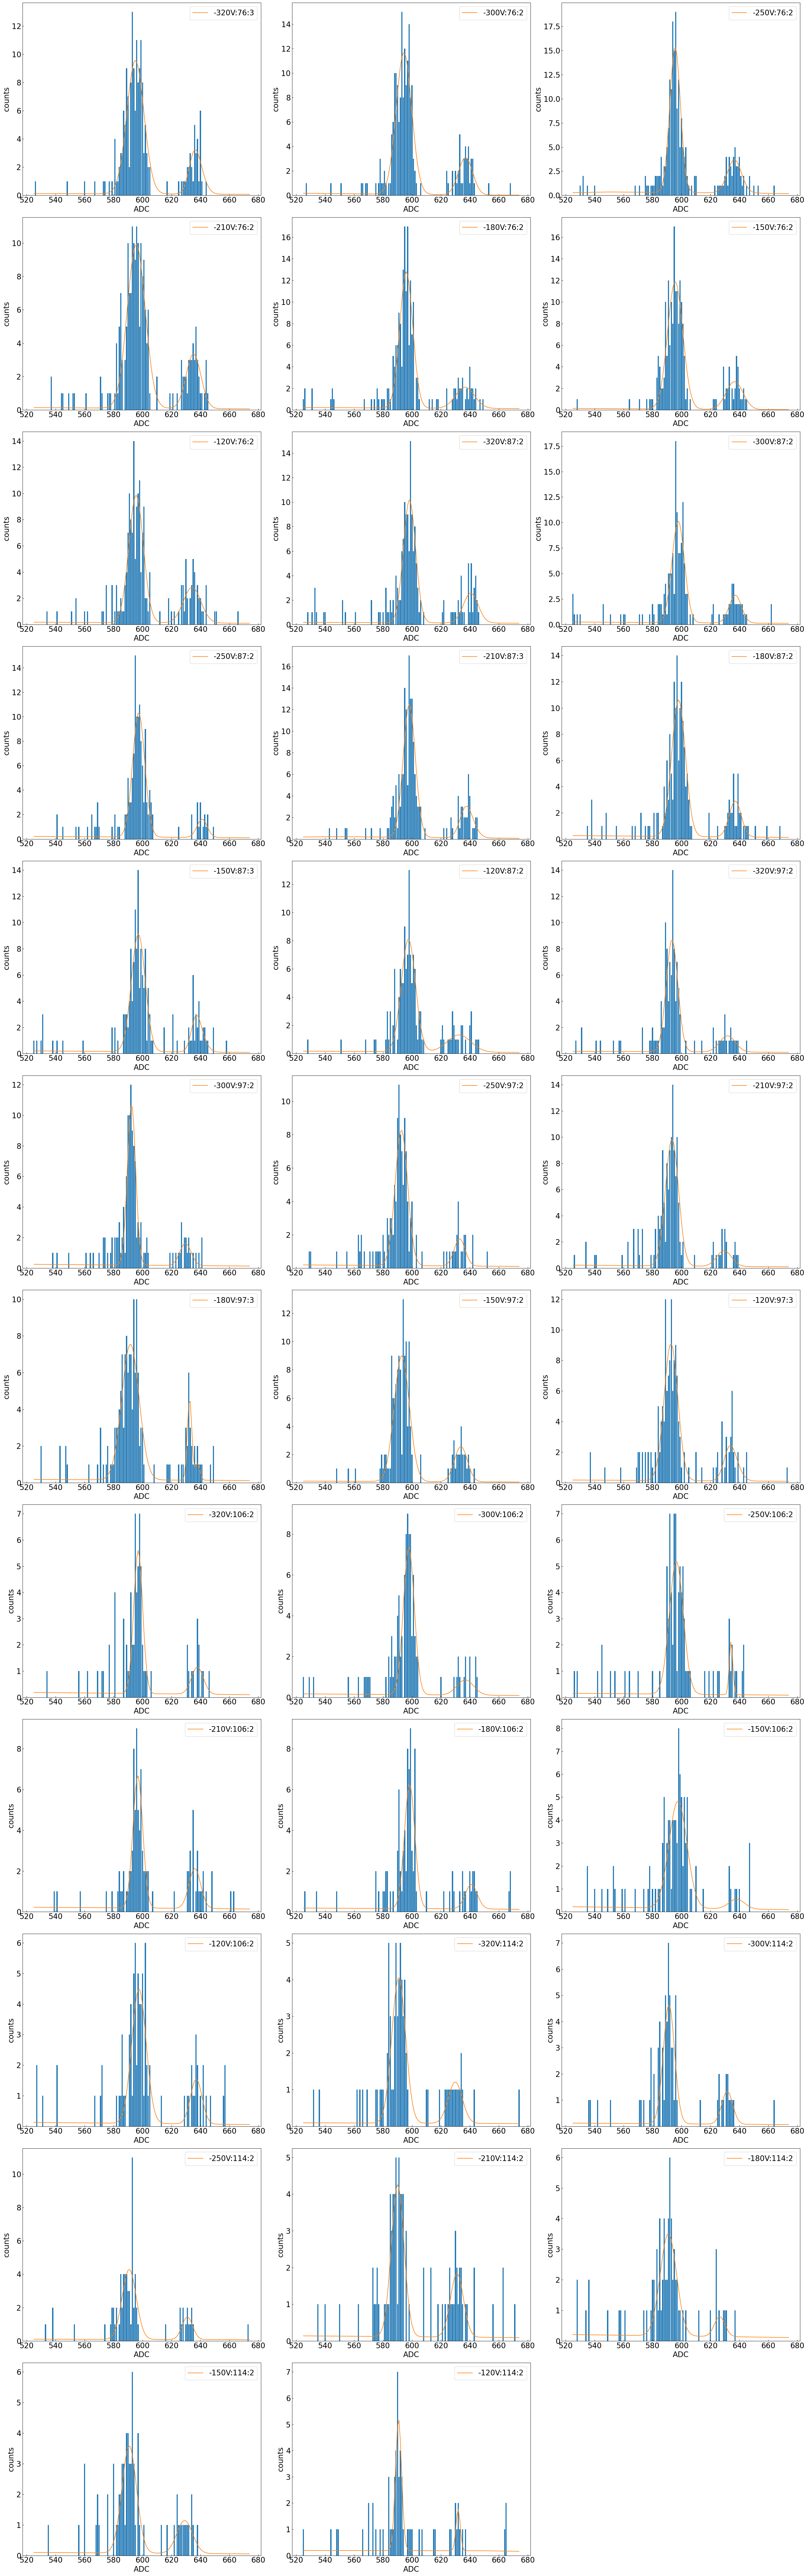

In [16]:
nrows,ncols=12,3
py.figure(figsize=(10*ncols,8*nrows))


x = np.arange(450,850)
conf['xray'] = 'OFF'
cnt = 0
for j in pix_index:
    for i in range(len(runs2)):
        cnt +=1
        ax=py.subplot(nrows,ncols,cnt)
#         ax.set_ylim(0,5)
        ax.set_ylabel('counts',size=20)
        ax.set_xlabel('ADC',size=20)
        ax.tick_params(direction='in',which='both',axis='both',labelsize=20)
        if dataAll[dataAll['pixel']==j].iloc[i]['CE']==3:
            conf['capture'] = 'three'
            Sn = SnCalibration()
            ax.plot(x[75:225],Sn.get_fit(x,*np.float64(dataAll[dataAll['pixel']==j].iloc[i]['ecap'].replace('[','').replace(']','').split()))[75:225],label = '%dV:%d:%d'%(bias2[i],j,dataAll[dataAll['pixel']==j].iloc[i]['CE']),color = '#ff7f0e')
            ax.bar(x[75:225],np.float64(dataAll[dataAll['pixel']==j].iloc[i]['CE hist'].replace('[','').replace(']','').split())[75:225])
            ax.legend(prop={'size':20})
            

        if dataAll[dataAll['pixel']==j].iloc[i]['CE']==2:

            conf['capture'] = 'two'
            Sn = SnCalibration()

            ax.plot(x[75:225],Sn.get_fit(x,*np.float64(dataAll[dataAll['pixel']==j].iloc[i]['ecap'].replace('[','').replace(']','').split()))[75:225],label = '%dV:%d:%d'%(bias2[i],j,dataAll[dataAll['pixel']==j].iloc[i]['CE']),color = '#ff7f0e')
            ax.bar(x[75:225],np.float64(dataAll[dataAll['pixel']==j].iloc[i]['CE hist'].replace('[','').replace(']','').split())[75:225])
            ax.legend(prop={'size':20})

        if dataAll[dataAll['pixel']==j].iloc[i]['CE']==1:
            conf['capture'] = 'one'
            Sn = SnCalibration()
            ax.bar(x[75:225],np.float64(dataAll[dataAll['pixel']==j].iloc[i]['CE hist'].replace('[','').replace(']','').split())[75:225])
            ax.plot(x[75:225],Sn.get_fit(x,*np.float64(dataAll[dataAll['pixel']==j].iloc[i]['ecap'].replace('[','').replace(']','').split()))[75:225],label = '%dV:%d:%d'%(bias2[i],j,dataAll[dataAll['pixel']==j].iloc[i]['CE']),color = '#ff7f0e')
            ax.legend(prop={'size':20})
py.tight_layout()

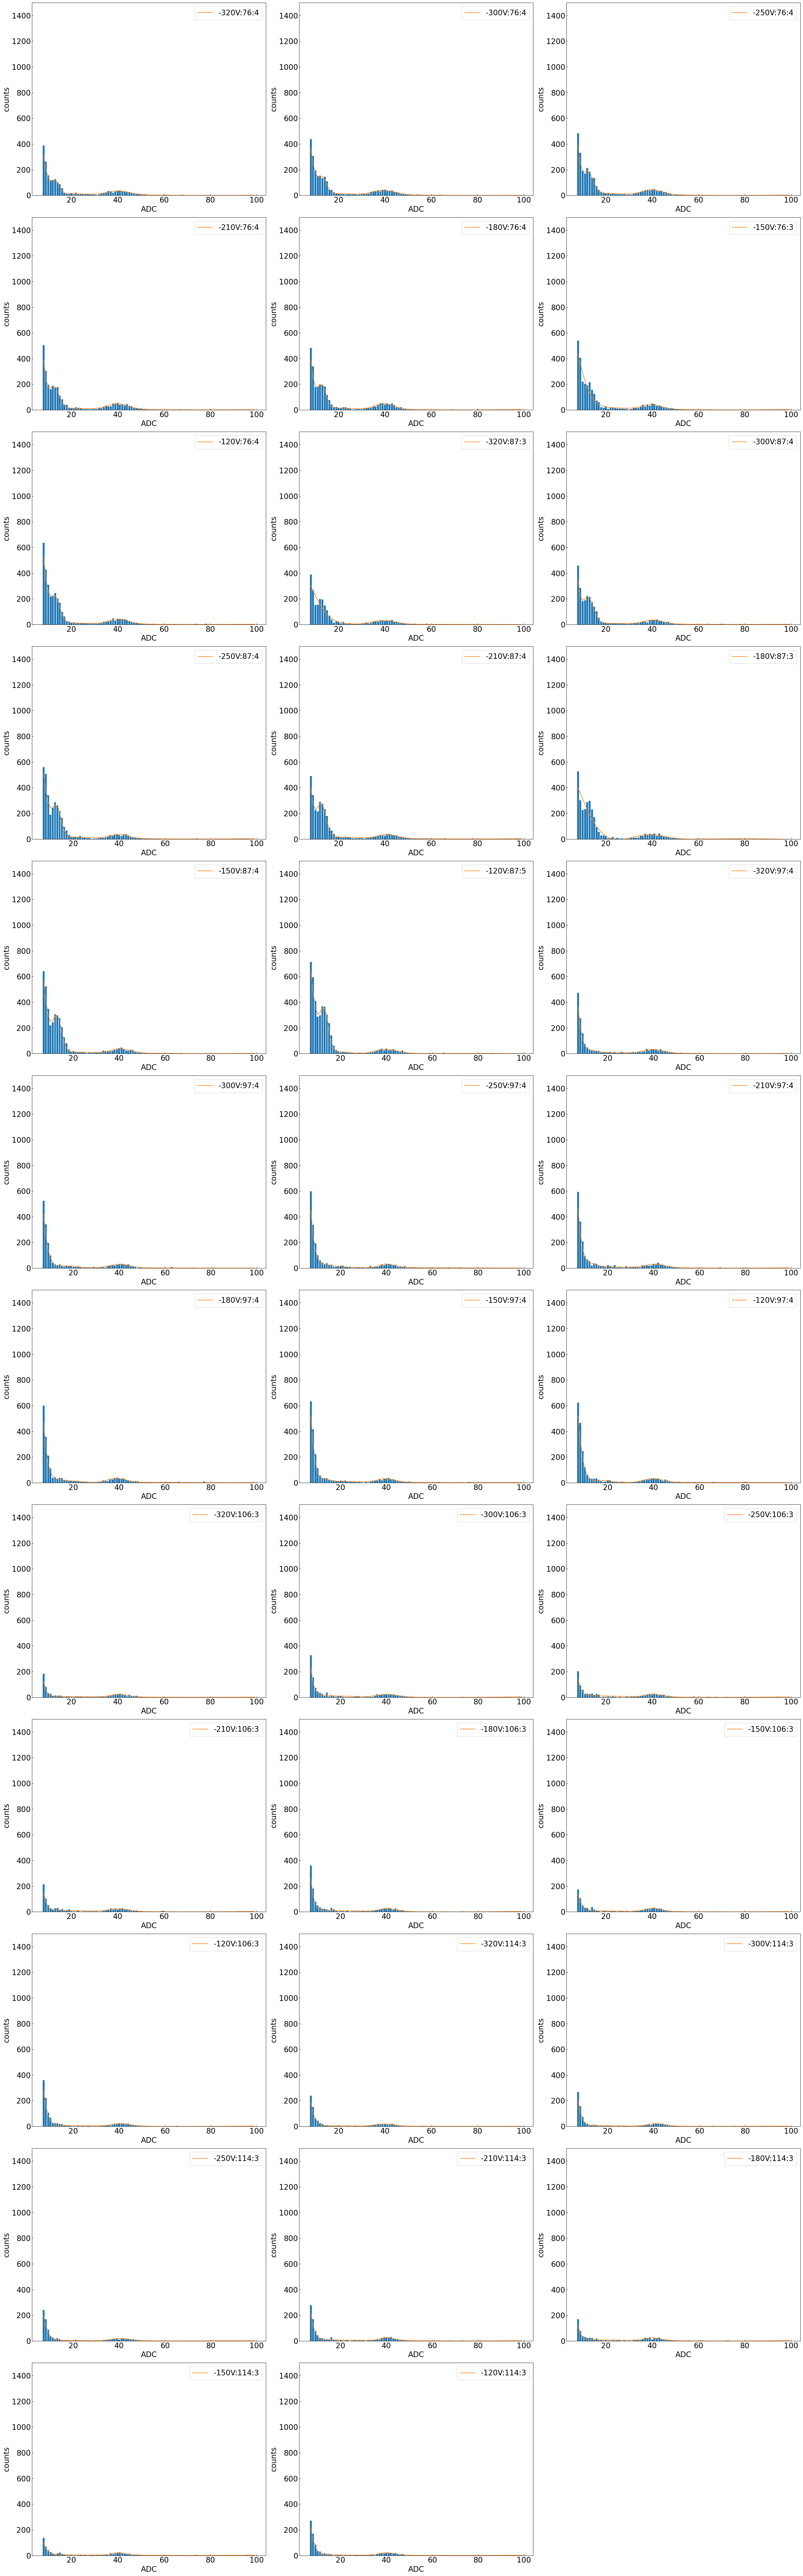

In [13]:
nrows,ncols=12,3
py.figure(figsize=(10*ncols,8*nrows))

conf['capture'] = 'OFF'
cnt = 0
for j in pix_index:
    for i in range(len(runs2)):
        cnt +=1
        ax=py.subplot(nrows,ncols,cnt)
        ax.set_ylim(0,1500)
        ax.set_ylabel('counts',size=20)
        ax.set_xlabel('ADC',size=20)
        ax.tick_params(direction='in',which='both',axis='both',labelsize=20)
        
        if dataAll[dataAll['pixel']==j].iloc[i]['Xray']==5:
            
            conf['xray'] = 'five'
            Sn = SnCalibration()
            thresh_start = 100-len(np.float64(dataAll[dataAll['pixel']==j].iloc[i]['Xray hist'].replace('[','').replace(']','').split()))
            x = np.arange(thresh_start,100)
            
            ax=py.subplot(nrows,ncols,cnt)
            ax.plot(x,Sn.get_fit(x,*np.float64(dataAll[dataAll['pixel']==j].iloc[i]['xray'].replace('[','').replace(']','').split())),label = '%dV:%d:%d'%(bias2[i],j,dataAll[dataAll['pixel']==j].iloc[i]['Xray']),color = '#ff7f0e')
            ax.bar(x,np.float64(dataAll[dataAll['pixel']==j].iloc[i]['Xray hist'].replace('[','').replace(']','').split()))
            ax.legend(prop={'size':20})

        if dataAll[dataAll['pixel']==j].iloc[i]['Xray']==4:

            conf['xray'] = 'four'
            Sn = SnCalibration()
            thresh_start = 100-len(np.float64(dataAll[dataAll['pixel']==j].iloc[i]['Xray hist'].replace('[','').replace(']','').split()))
            x = np.arange(thresh_start,100)

            ax=py.subplot(nrows,ncols,cnt)
            ax.plot(x,Sn.get_fit(x,*np.float64(dataAll[dataAll['pixel']==j].iloc[i]['xray'].replace('[','').replace(']','').split())),label = '%dV:%d:%d'%(bias2[i],j,dataAll[dataAll['pixel']==j].iloc[i]['Xray']),color = '#ff7f0e')
            ax.bar(x,np.float64(dataAll[dataAll['pixel']==j].iloc[i]['Xray hist'].replace('[','').replace(']','').split()))
            ax.legend(prop={'size':20})

        if dataAll[dataAll['pixel']==j].iloc[i]['Xray']==3:

            conf['xray'] = 'three'
            Sn = SnCalibration()
            thresh_start = 100-len(np.float64(dataAll[dataAll['pixel']==j].iloc[i]['Xray hist'].replace('[','').replace(']','').split()))
            x = np.arange(thresh_start,100)

            ax=py.subplot(nrows,ncols,cnt)

            ax.plot(x,Sn.get_fit(x,*np.float64(dataAll[dataAll['pixel']==j].iloc[i]['xray'].replace('[','').replace(']','').split())),label = '%dV:%d:%d'%(bias2[i],j,dataAll[dataAll['pixel']==j].iloc[i]['Xray']),color = '#ff7f0e')
            ax.bar(x,np.float64(dataAll[dataAll['pixel']==j].iloc[i]['Xray hist'].replace('[','').replace(']','').split()))
            
            ax.legend(prop={'size':20})

#         ax.set_ylim(0,500)
py.tight_layout()

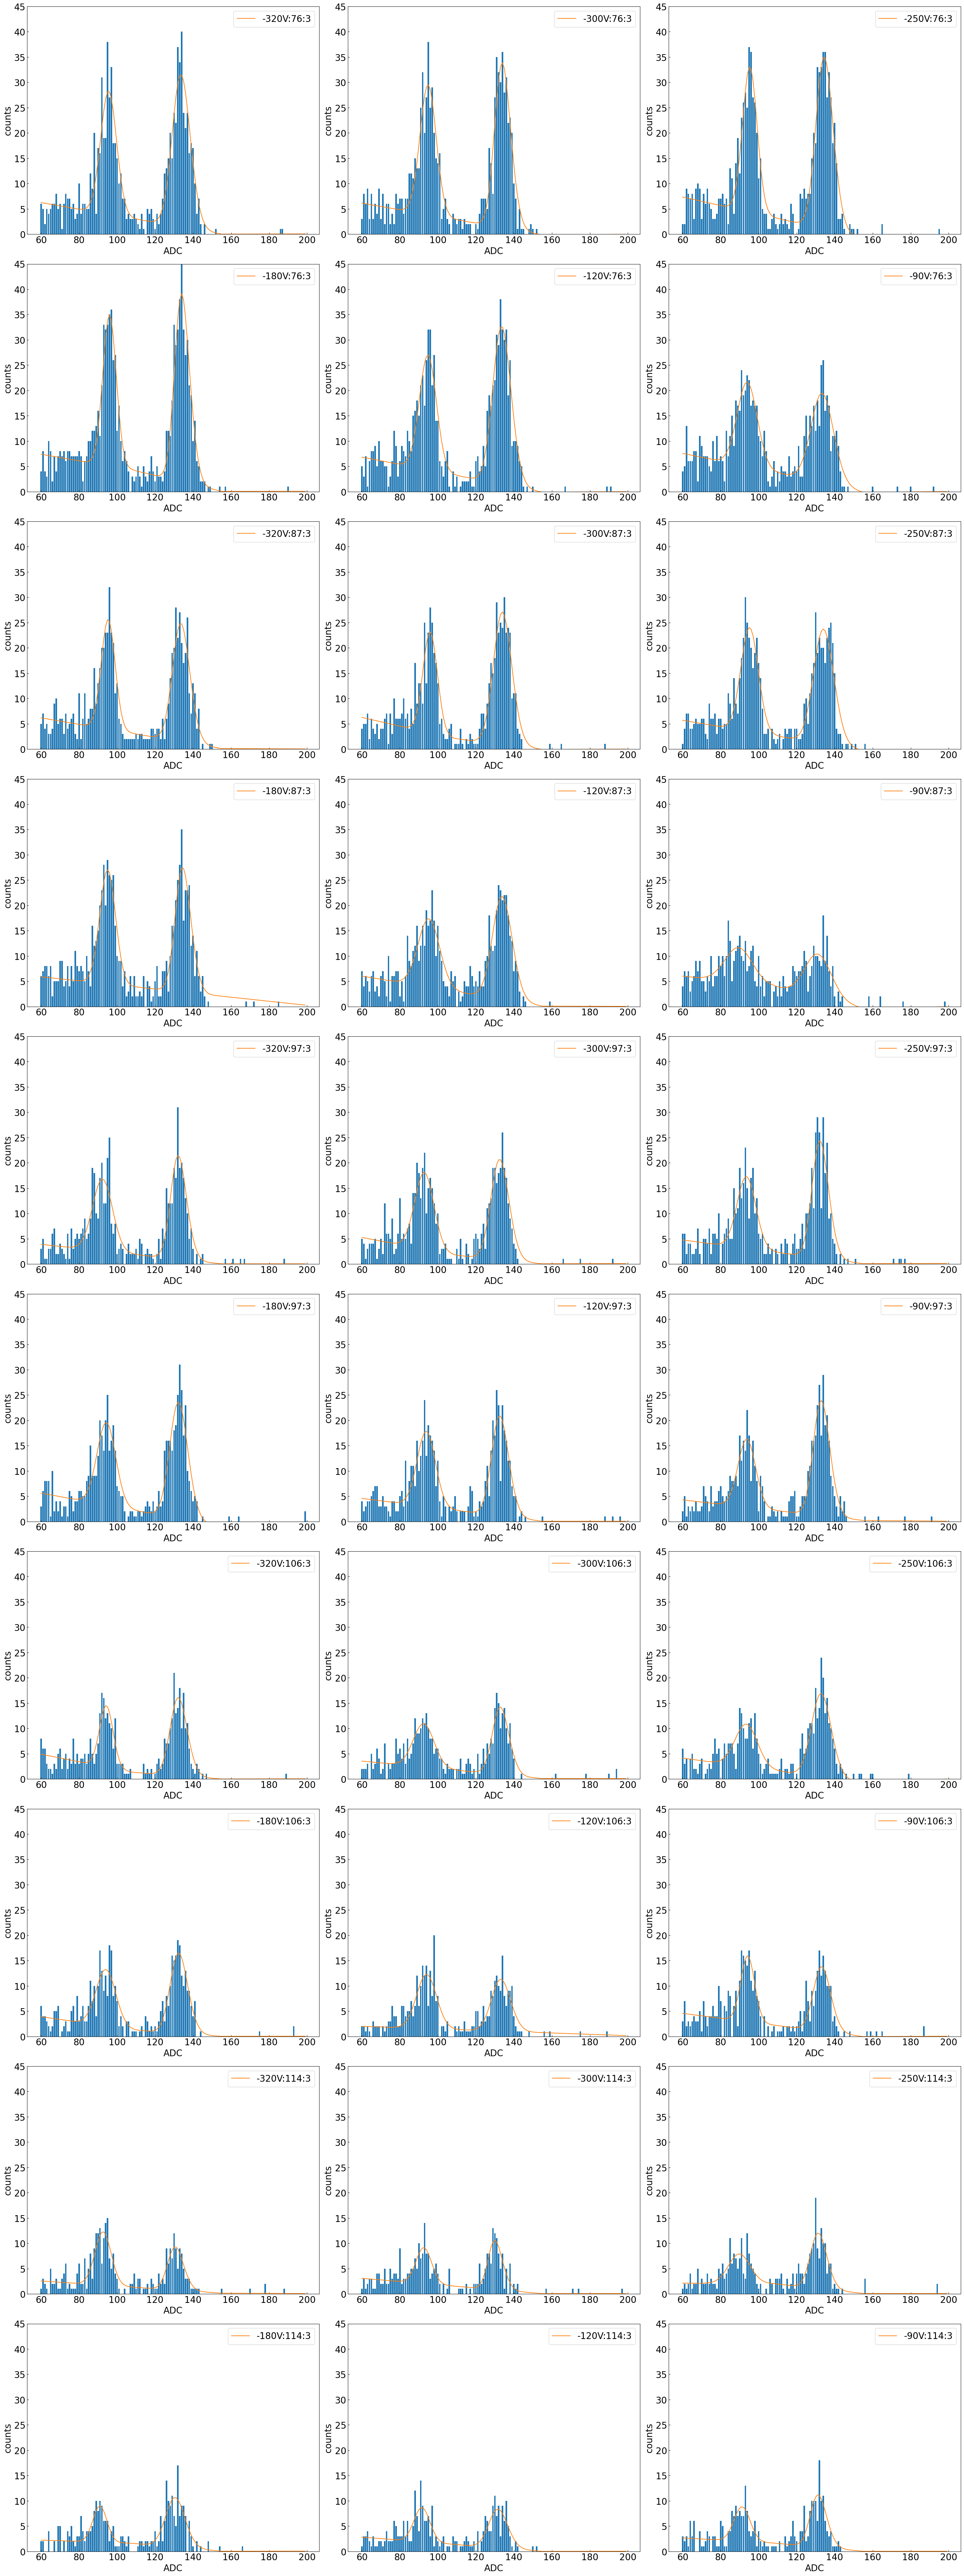

In [11]:
nrows,ncols=10,3
py.figure(figsize=(10*ncols,8*nrows))


x = np.arange(60,250)
conf['xray'] = 'OFF'
conf['new'] = 'OFF'
cnt = 0
for j in pix_index:
    for i in range(len(runs_Cd)):
        cnt +=1
        ax=py.subplot(nrows,ncols,cnt)
        ax.set_ylim(0,45)
        ax.set_ylabel('counts',size=20)
        ax.set_xlabel('ADC',size=20)
        ax.tick_params(direction='in',which='both',axis='both',labelsize=20)
        
        if dataAll_Cd[dataAll_Cd['pixel']==j].iloc[i]['CE']==3:
            conf['capture'] = 'three'
            Cd = CdCalibration()
            ax.plot(x[0:140],Cd.get_fit(x,*np.float64(dataAll_Cd[dataAll_Cd['pixel']==j].iloc[i]['ecap'].replace('[','').replace(']','').split()))[0:140],label = '%dV:%d:%d'%(bias[i],j,dataAll_Cd[dataAll_Cd['pixel']==j].iloc[i]['CE']),color = '#ff7f0e')
            ax.bar(x[0:140],np.float64(dataAll_Cd[dataAll_Cd['pixel']==j].iloc[i]['CE hist'].replace('[','').replace(']','').split())[0:140])
            ax.legend(prop={'size':20})
            

        if dataAll_Cd[dataAll_Cd['pixel']==j].iloc[i]['CE']==2:
            conf['capture'] = 'two'
            Cd = CdCalibration()
            ax.plot(x[0:140],Cd.get_fit(x,*np.float64(dataAll_Cd[dataAll_Cd['pixel']==j].iloc[i]['ecap'].replace('[','').replace(']','').split()))[0:140],label = '%dV:%d:%d'%(bias[i],j,dataAll_Cd[dataAll_Cd['pixel']==j].iloc[i]['CE']),color = '#ff7f0e')
            ax.bar(x[0:140],np.float64(dataAll_Cd[dataAll_Cd['pixel']==j].iloc[i]['CE hist'].replace('[','').replace(']','').split())[0:140])
            
            ax.legend(prop={'size':20})

        if dataAll_Cd[dataAll_Cd['pixel']==j].iloc[i]['CE']==1:
            conf['capture'] = 'one'
            Cd = CdCalibration()
            ax.plot(x[0:140],Cd.get_fit(x,*np.float64(dataAll_Cd[dataAll_Cd['pixel']==j].iloc[i]['ecap'].replace('[','').replace(']','').split()))[0:140],label = '%dV:%d:%d'%(bias[i],j,dataAll_Cd[dataAll_Cd['pixel']==j].iloc[i]['CE']),color = '#ff7f0e')
            ax.bar(x[0:140],np.float64(dataAll_Cd[dataAll_Cd['pixel']==j].iloc[i]['CE hist'].replace('[','').replace(']','').split())[0:140])
            
            ax.legend(prop={'size':20})
py.tight_layout()

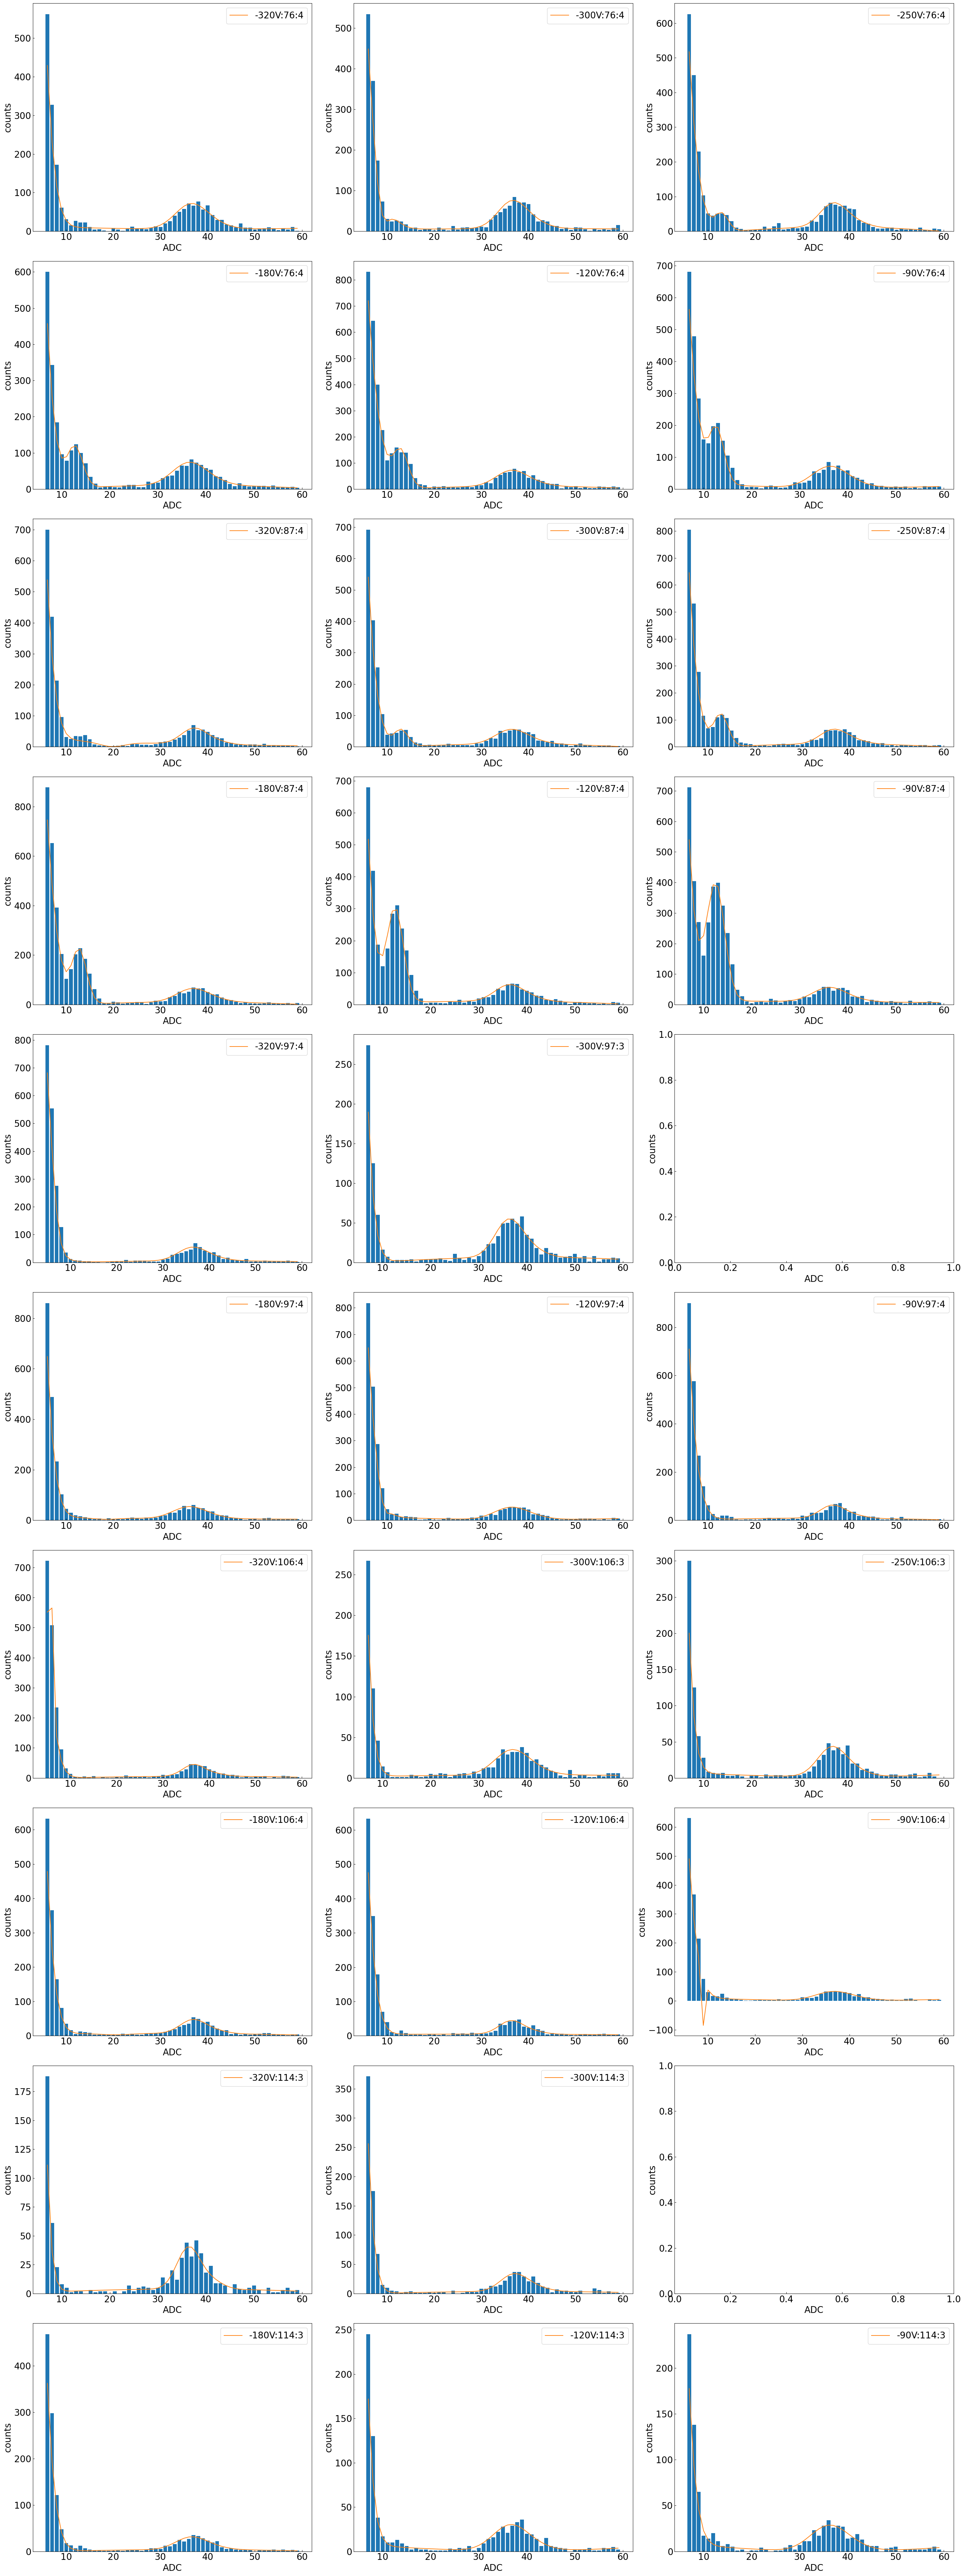

In [12]:
nrows,ncols=10,3
py.figure(figsize=(10*ncols,8*nrows))


x = np.arange(0,60)
conf['capture'] = 'OFF'
cnt = 0
for j in pix_index:
    for i in range(len(runs_Cd)):
        cnt +=1
        ax=py.subplot(nrows,ncols,cnt)
#         ax.set_ylim(0,1500)
        ax.tick_params(direction='in',which='both',axis='both',labelsize=20)
        ax.set_ylabel('counts',size=20)
        ax.set_xlabel('ADC',size=20)
        if dataAll_Cd[dataAll_Cd['pixel']==j].iloc[i]['Xray']==5:

            conf['xray'] = 'five'
            Cd = CdCalibration()
            thresh_start = 60-len(np.float64(dataAll_Cd[dataAll_Cd['pixel']==j].iloc[i]['Xray hist'].replace('[','').replace(']','').split()))
            x = np.arange(thresh_start,60)
            
            ax=py.subplot(nrows,ncols,cnt)
            ax.plot(x,Cd.get_fit(x,*np.float64(dataAll_Cd[dataAll_Cd['pixel']==j].iloc[i]['xray'].replace('[','').replace(']','').split())),label = '%dV:%d:%d'%(bias[i],j,dataAll_Cd[dataAll_Cd['pixel']==j].iloc[i]['Xray']),color = '#ff7f0e')
            ax.bar(x,np.float64(dataAll_Cd[dataAll_Cd['pixel']==j].iloc[i]['Xray hist'].replace('[','').replace(']','').split()))
            ax.legend(prop={'size':20})

        if dataAll_Cd[dataAll_Cd['pixel']==j].iloc[i]['Xray']==4:

            conf['xray'] = 'four'
            Cd = CdCalibration()
            thresh_start = 60-len(np.float64(dataAll_Cd[dataAll_Cd['pixel']==j].iloc[i]['Xray hist'].replace('[','').replace(']','').split()))
            x = np.arange(thresh_start,60)
            
            ax=py.subplot(nrows,ncols,cnt)
            ax.plot(x,Cd.get_fit(x,*np.float64(dataAll_Cd[dataAll_Cd['pixel']==j].iloc[i]['xray'].replace('[','').replace(']','').split())),label = '%dV:%d:%d'%(bias[i],j,dataAll_Cd[dataAll_Cd['pixel']==j].iloc[i]['Xray']),color = '#ff7f0e')
            ax.bar(x,np.float64(dataAll_Cd[dataAll_Cd['pixel']==j].iloc[i]['Xray hist'].replace('[','').replace(']','').split()))
            ax.legend(prop={'size':20})

        if dataAll_Cd[dataAll_Cd['pixel']==j].iloc[i]['Xray']==3:

            conf['xray'] = 'three'
            Cd = CdCalibration()
            thresh_start = 60-len(np.float64(dataAll_Cd[dataAll_Cd['pixel']==j].iloc[i]['Xray hist'].replace('[','').replace(']','').split()))
            x = np.arange(thresh_start,60)
            
            ax=py.subplot(nrows,ncols,cnt)

            ax.plot(x,Cd.get_fit(x,*np.float64(dataAll_Cd[dataAll_Cd['pixel']==j].iloc[i]['xray'].replace('[','').replace(']','').split())),label = '%dV:%d:%d'%(bias[i],j,dataAll_Cd[dataAll_Cd['pixel']==j].iloc[i]['Xray']),color = '#ff7f0e')
            ax.bar(x,np.float64(dataAll_Cd[dataAll_Cd['pixel']==j].iloc[i]['Xray hist'].replace('[','').replace(']','').split()))
            ax.legend(prop={'size':20})

#         ax.set_ylim(0,500)
py.tight_layout()